In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##Loading the clean data
df=pd.read_csv('finaccess2024_cleaned.csv')
print(f" Clean data loaded : {df.shape[0]} rows {df.shape[1]} columns")

ORDER =['Improved','Stayed the same','Worsened']
COLOURS=['#2ecc71','#f39c12','#e74c3c'] #Green for improved, Amber for stayed the same and red for worsened

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

 Clean data loaded : 20876 rows 28 columns


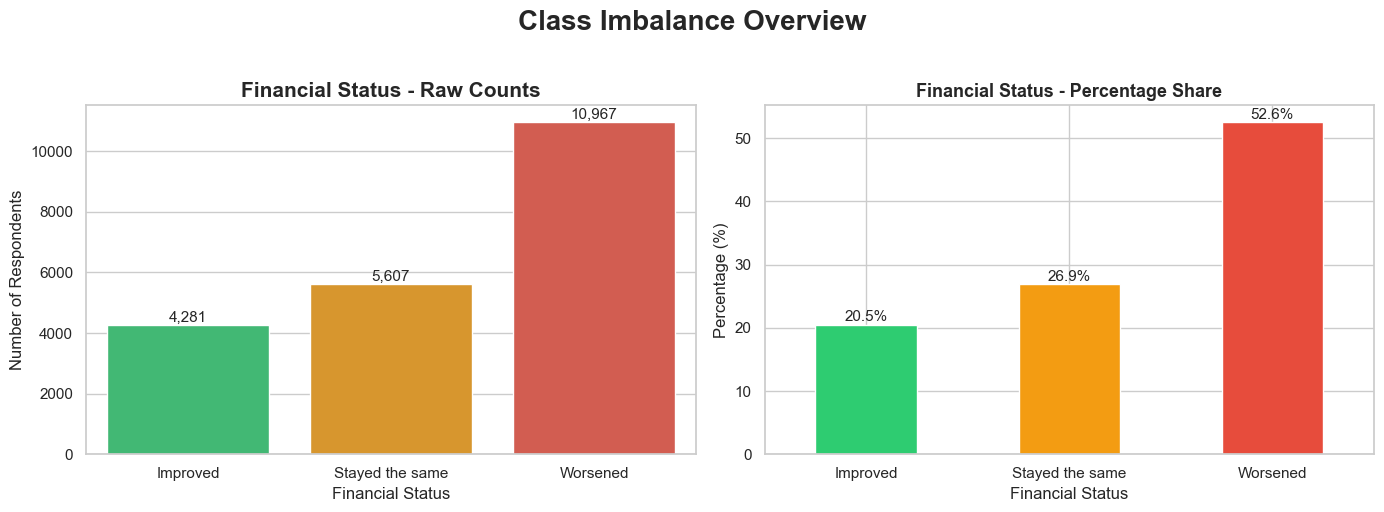

In [2]:
##Plot 1- Target Distribution -also okay

fig,axes= plt.subplots(1,2, figsize=(14,5))

sns.countplot(
    data=df,
    x='financial_status',
    order=ORDER,
    hue='financial_status',
    hue_order=ORDER,
    palette=dict(zip(ORDER,COLOURS)),
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Financial Status - Raw Counts',fontsize=15, fontweight='bold')
axes[0].set_xlabel('Financial Status')
axes[0].set_ylabel('Number of Respondents')

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() /2,p.get_height()),
        ha='center',va='bottom', fontsize=11
    )

pct=df['financial_status'].value_counts(normalize=True) * 100
pct = pct.reindex(ORDER)

pct.plot(kind='bar', color=COLOURS,ax=axes[1], edgecolor='white')
axes[1].set_title('Financial Status - Percentage Share', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Financial Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(ORDER, rotation=0)

#Adding pct label on each bar
for i, v in enumerate(pct):
    axes[1].text(i,v + 0.5,f'{v:.1f}%',ha='center', fontsize=11)
    
plt.suptitle('Class Imbalance Overview',fontsize=20,fontweight='bold',y=1.02)
plt.tight_layout()
# plt.savefig('plot1_target_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

#Insight for the above plot

The majority of Kenyan respondents reported a worsened financial status, making it the most dominant outcome in the data. This shows widespread financial stress across the population. The "Improved" group represents the smallest share, suggesting that upward financial mobility is the exception rather than the normal. This distribution sets the context for all other plots which is studying a population under financial pressure.

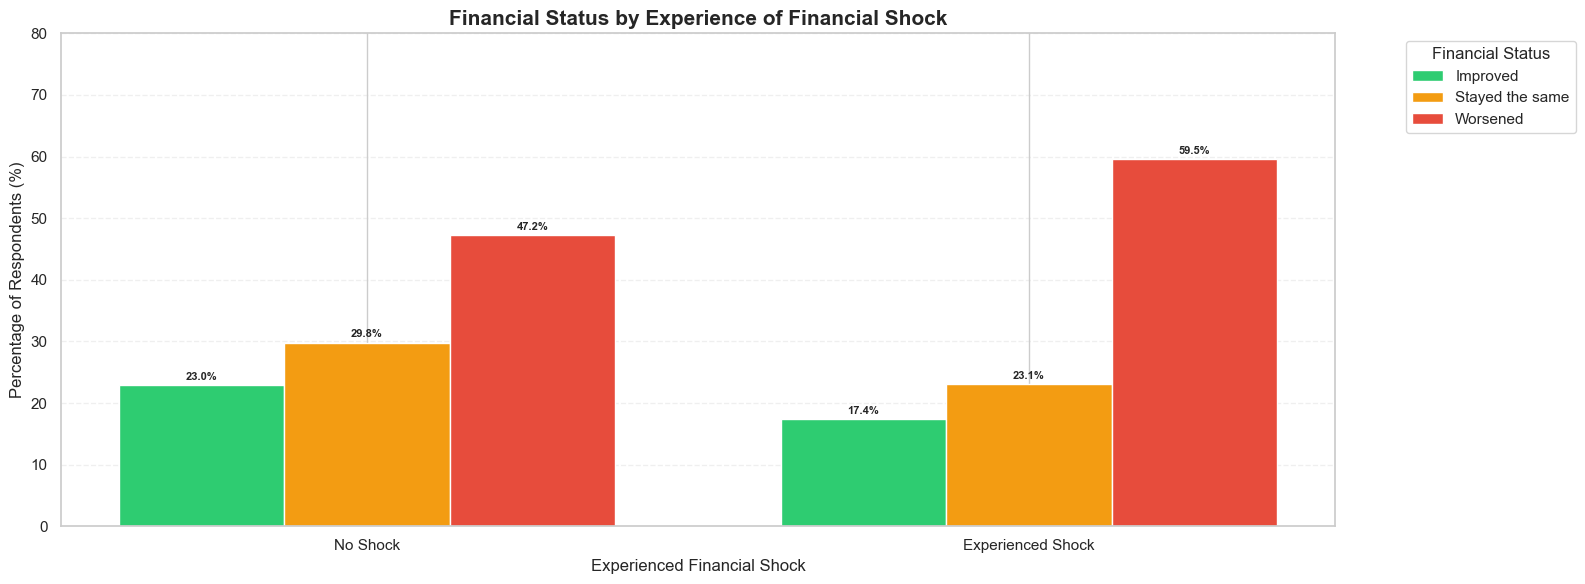


Exact percentages: 
financial_status   Improved  Stayed the same  Worsened
experienced_shock                                     
No                    22.95            29.82     47.23
Yes                   17.38            23.08     59.54

Worsened gap (shock vs no shock): 12.3 percentage points


In [3]:
##Plot 2- Financial Shock Vs Financial Status
fig, ax = plt.subplots(figsize=(16, 6))

shock_ct = pd.crosstab(
    df['experienced_shock'],
    df['financial_status'],
    normalize='index'
) * 100

shock_ct = shock_ct[ORDER]
x = range(len(shock_ct.index))
width = 0.25
offsets = [-width, 0, width]


for status, colour, offset in zip(ORDER, COLOURS, offsets):
    bars = ax.bar(
        [pos + offset for pos in x],
        shock_ct[status],
        width=width,
        color=colour,
        edgecolor='white',
        label=status
    )
    
    # Add value labels on bars - MOVED INSIDE the loop
    for bar in bars:
        height = bar.get_height()
        if height > 3:  # Label bars greater than 3%
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                f'{height:.1f}%',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold'
            )

# Customize the bar chart
ax.set_title('Financial Status by Experience of Financial Shock', fontsize=15, fontweight='bold')
ax.set_xlabel('Experienced Financial Shock', fontsize=12)
ax.set_ylabel('Percentage of Respondents (%)', fontsize=12)
ax.set_xticks(x)  # Set the ticks first
ax.set_xticklabels(['No Shock', 'Experienced Shock'], fontsize=11)  # Then set the labels
ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.3, linestyle='--')



plt.tight_layout()
# plt.savefig('Plot_2_Shock_vs_Status.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nExact percentages: ")
print(shock_ct.round(2))

diff = (shock_ct.loc['Yes', 'Worsened'] - shock_ct.loc['No', 'Worsened'])
print(f"\nWorsened gap (shock vs no shock): {diff:.1f} percentage points")

##Insight for the above cell

Respondents who experienced a financial shock show a clearly higher proportion of "Worsened" financial status compared to those who did not. This confirms that financial shocks eg.job loss, illness, drought, etc. are a strong driver of financial decline. However, even those who didn't experience a shock still show a high "Worsened" rate, suggesting that financial shocks are not the only factors that play a role in declining financial outcomes.

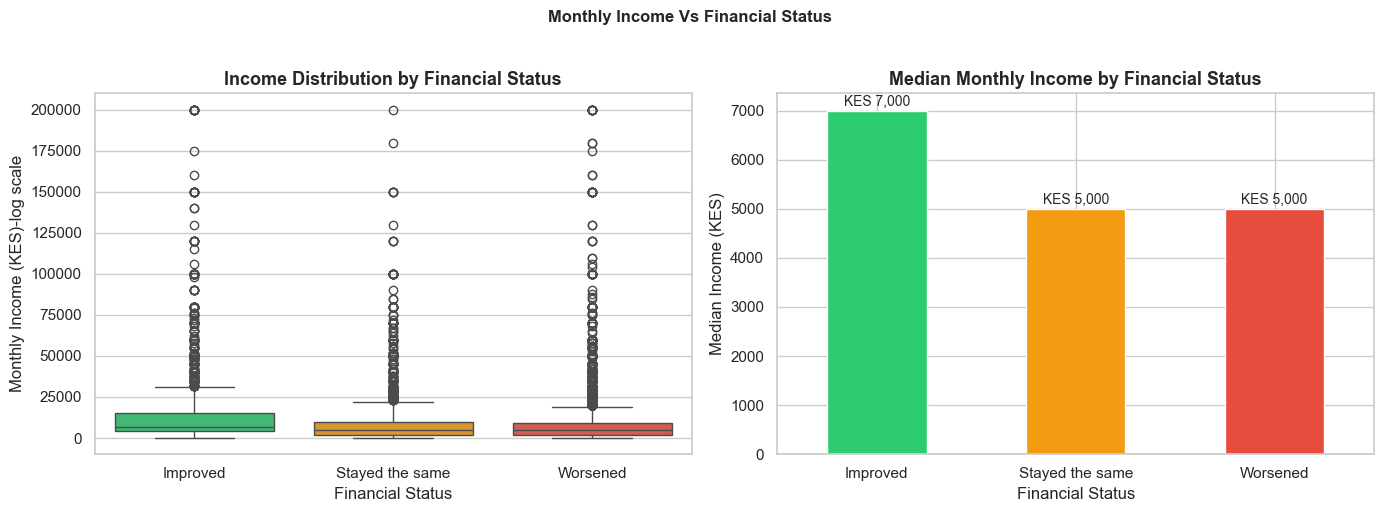


Median Income by financial status:
financial_status
Improved           7000.0
Stayed the same    5000.0
Worsened           5000.0
Name: monthly_income, dtype: float64

OUTLIER ANALYSIS Income Distribution by Financial Status

Group: Improved
  Respondents:       4,281
  Q1:                KES 4,000
  Q3:                KES 15,000
  IQR:               KES 11,000
  Lower fence:       KES -12,500
  Upper fence:       KES 31,500
  Total outliers:    452 (10.6%)
  Low outliers:      0
  High outliers:     452
  Outlier min:       KES 32,000
  Outlier max:       KES 200,000

Group: Stayed the same
  Respondents:       5,607
  Q1:                KES 2,000
  Q3:                KES 10,000
  IQR:               KES 8,000
  Lower fence:       KES -10,000
  Upper fence:       KES 22,000
  Total outliers:    473 (8.4%)
  Low outliers:      0
  High outliers:     473
  Outlier min:       KES 23,000
  Outlier max:       KES 200,000

Group: Worsened
  Respondents:       10,967
  Q1:                KES

In [4]:
##Plot3- Income Distribution by Financial Status AND Median monthly income by Financial Status
fig,axes=plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    data=df,
    x='financial_status',
    hue='financial_status',
    hue_order=ORDER,
    y='monthly_income',
    order=ORDER,
    palette=dict(zip(ORDER,COLOURS)),
    legend=False,
    ax=axes[0]
)
axes[0].set_ylabel('log')

axes[0].set_title('Income Distribution by Financial Status',fontsize=13, fontweight='bold')
axes[0].set_xlabel('Financial Status')
axes[0].set_ylabel('Monthly Income (KES)-log scale')

medians=df.groupby('financial_status')['monthly_income'].median()


medians=medians.reindex(ORDER)
medians.plot(kind='bar',color=COLOURS,ax=axes[1], edgecolor='white')
axes[1].set_title('Median Monthly Income by Financial Status',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Financial Status')
axes[1].set_ylabel('Median Income (KES)')
axes[1].set_xticklabels(ORDER, rotation=0)

for i,v in enumerate(medians):
    axes[1].text(i,v +100, f'KES {v:,.0f}',ha='center',fontsize='10')

plt.suptitle('Monthly Income Vs Financial Status ',fontsize=12, fontweight='bold',y=1.02)
plt.tight_layout()
#plt.savefig('plot3_income_vs_status.png',dpi=150,bbox_inches='tight')
plt.show()

print(f"\nMedian Income by financial status:")
print(medians)

print()
print("="*20)
print("OUTLIER ANALYSIS Income Distribution by Financial Status")
print("="*20)

for group in ORDER:
    group_data=df[df['financial_status']==group]['monthly_income']
    Q1=group_data.quantile(0.25)
    Q3=group_data.quantile(0.75)
    IQR=Q3-Q1
    
    lower_fence=Q1-1.5 *IQR
    upper_fence=Q3+1.5*IQR
    
    outliers=group_data[
        (group_data<lower_fence)| (group_data> upper_fence)
    ]
    low_outliers= group_data[group_data<lower_fence]
    high_outliers= group_data[group_data>upper_fence]
    
    print(f"\nGroup: {group}")
    print(f"  Respondents:       {len(group_data):,}")
    print(f"  Q1:                KES {Q1:,.0f}")
    print(f"  Q3:                KES {Q3:,.0f}")
    print(f"  IQR:               KES {IQR:,.0f}")
    print(f"  Lower fence:       KES {lower_fence:,.0f}")
    print(f"  Upper fence:       KES {upper_fence:,.0f}")
    print(f"  Total outliers:    {len(outliers):,} "
          f"({len(outliers)/len(group_data)*100:.1f}%)")
    print(f"  Low outliers:      {len(low_outliers):,}")
    print(f"  High outliers:     {len(high_outliers):,}")
    print(f"  Outlier min:       KES {outliers.min():,.0f}")
    print(f"  Outlier max:       KES {outliers.max():,.0f}")


##INSIGHT

There is a clear positive relationship between income and financial status — respondents whose finances improved tend to have higher median incomes than those who worsened. However, the box plots likely show significant overlap and outliers across all three groups, indicating that income alone does not fully determine financial outcomes. Even some higher-income respondents experienced worsened status, pointing to the role of spending, debt, and shocks.



Formal Savings Usage:
financial_status  Improved  Stayed the same  Worsened
Savings_formal                                       
Non-usage            15.48            29.12     55.40
Usage                26.88            24.08     49.04

Formal Loan Usage:
financial_status  Improved  Stayed the same  Worsened
Loan_formal                                          
Non-usage            18.89            29.71     51.40
Usage                22.89            22.80     54.31


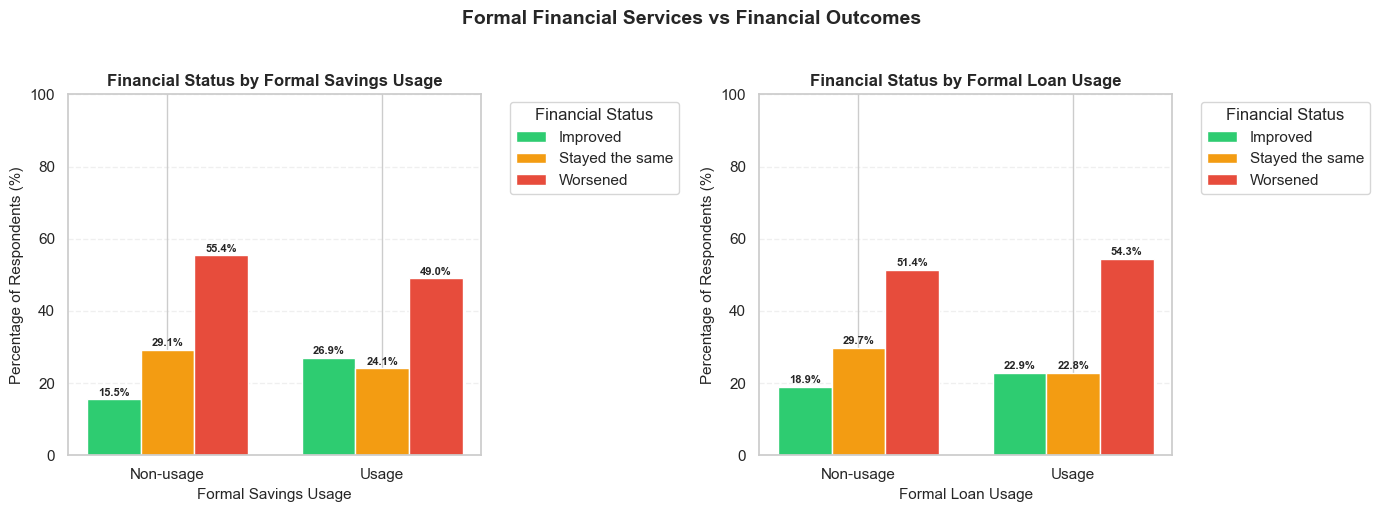

In [5]:
##Plot Formal Services Vs Financial Outcomes and Financial status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['Savings_formal', 'Loan_formal'],
    ['Formal Savings Usage', 'Formal Loan Usage']
):
    # Create crosstab
    ct = pd.crosstab(df[col], df['financial_status'], normalize='index') * 100
    ct = ct[ORDER]  # Reorder columns: Improved, Stayed the same, Worsened
    
    # Prepare data for grouped bar chart
    categories = ['Non-usage', 'Usage']  # 0 = Non-usage, 1 = Usage
    x = range(len(categories))
    width = 0.25  # Width of each bar
    offsets = [-width, 0, width]  # Offsets for the three statuses
    
    # Create grouped bars
    for i, (status, colour, offset) in enumerate(zip(ORDER, COLOURS, offsets)):
        bars = ax.bar(
            [pos + offset for pos in x],
            ct[status],
            width=width,
            color=colour,
            edgecolor='white',
            label=status
        )
        
        # Add value labels on bars
        for bar in bars:
            if bar.get_height() > 3:  # Only label bars > 3%
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}%',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold'
                )
    
    
    ax.set_title(f'Financial Status by {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Percentage of Respondents (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    
    print(f"\n{title}:")
    print(ct.round(2))
    
    
plt.suptitle('Formal Financial Services vs Financial Outcomes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('plot4_formal_services.png', dpi=150, bbox_inches='tight')
plt.show()

##INSIGHT

Respondents who use formal savings services show a higher proportion of "Improved" financial status compared to non-users, suggesting that access to and use of formal savings is associated with better financial outcomes. For formal loans,it is not very direct as usage does not strongly predict improvement, possibly because loans can either support growth or increase debt burden depending on the borrower's situation.

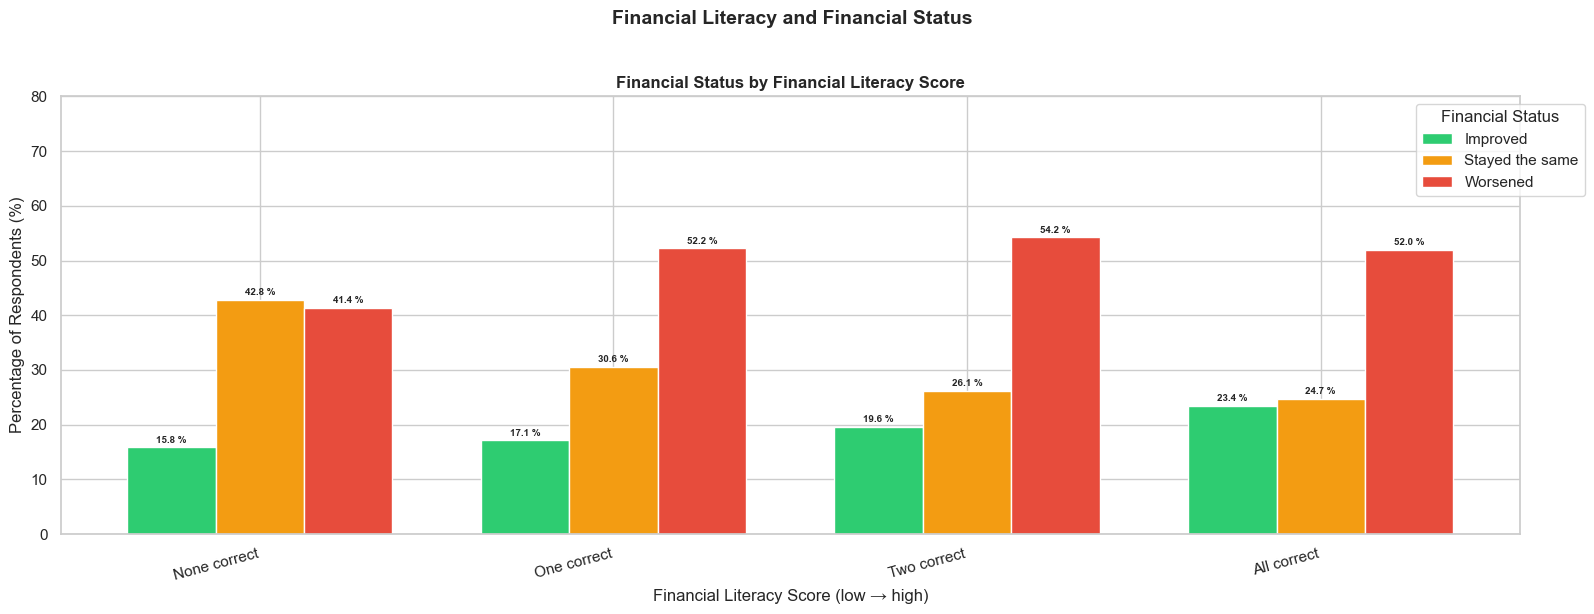


Financial literacy crosstab (%):
financial_status  Improved  Stayed the same  Worsened
fl_score                                             
None correct          15.8             42.8      41.4
One correct           17.1             30.6      52.2
Two correct           19.6             26.1      54.2
All correct           23.4             24.7      52.0

Worsened % by literacy level:
fl_score
None correct    41.4
One correct     52.2
Two correct     54.2
All correct     52.0
Name: Worsened, dtype: float64

Difference (None correct vs All correct — Worsened %):


In [6]:
##Plot 5: Financial Literacy by Financial Status

FL_ORDER=['None correct','One correct','Two correct','All correct']

fl_ct =pd.crosstab(
    df['fl_score'],
    df['financial_status'],
    normalize='index'
)*100

fl_ct = fl_ct.reindex(FL_ORDER)

fl_ct=fl_ct[ORDER]
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
x= range(len(FL_ORDER))
width=0.25
offsets=[-width,0,width]

for i,(status,colour,offset) in enumerate (
    zip(ORDER,COLOURS,offsets)
):
    bars = ax.bar(
        [pos+offset for pos in x],
        fl_ct[status],
        width=width,
        color=colour,
        edgecolor='white',
        label=status 
    )

    for bar in bars:
        if bar.get_height() > 5:
            ax.text(
                bar.get_x() + bar.get_width() /2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f} %',
                ha='center',va='bottom',
                fontsize=7, fontweight='bold'
            )
        
ax.set_title('Financial Status by Financial Literacy Score',fontsize=12, fontweight='bold')
ax.set_xlabel('Financial Literacy Score (low → high)')
ax.set_ylabel('Percentage of Respondents (%)')
ax.set_xticks(x)

ax.set_xticklabels(FL_ORDER, rotation=15, ha='right')
ax.legend(title='Financial Status',bbox_to_anchor=(1.05,1), loc='upper right')
ax.set_ylim(0,80)



plt.suptitle('Financial Literacy and Financial Status',fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('plot5_literacy_vs_status.png',dpi=150, bbox_inches='tight')
plt.show()

print("\nFinancial literacy crosstab (%):")
print(fl_ct.round(1))
print("\nWorsened % by literacy level:")
print(fl_ct['Worsened'].round(1))
print(f"\nDifference (None correct vs All correct — Worsened %):")


##Insights

Financial literacy shows a gradual but meaningful relationship with financial outcomes. Respondents who answered "All correct" on the literacy assessment have a higher share of "Improved" status compared to those with "None correct." while those with zero correct answers are excessively represented in the "Worsened" group. This suggests that financial literacy is an important factor as people who understand financial concepts are better equipped to make decisions that improve their situation.

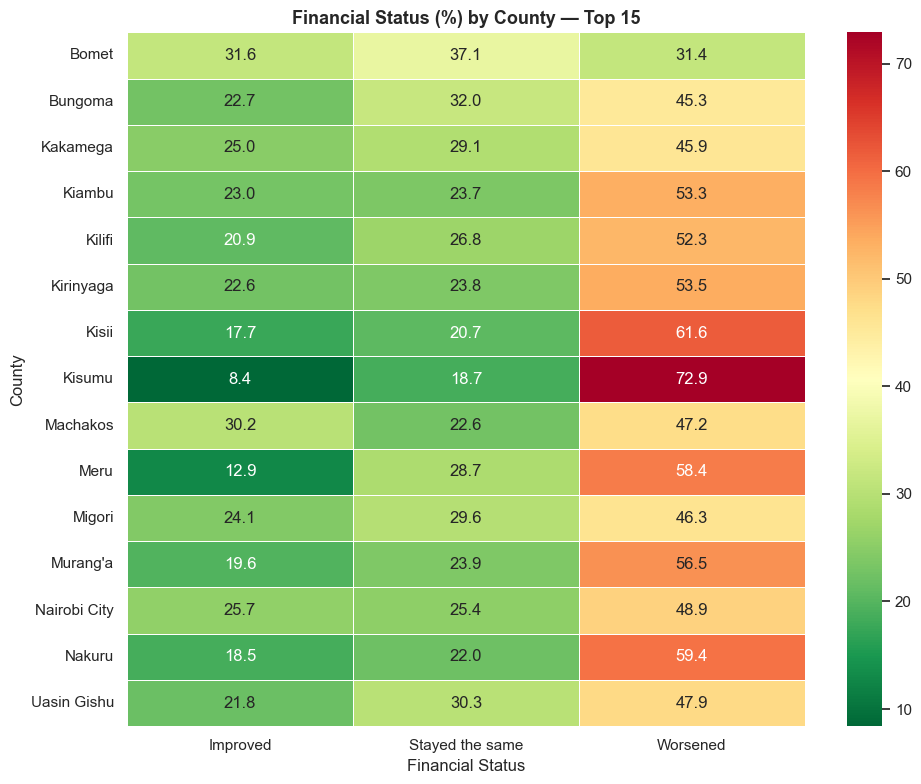


Top 5 counties by Worsened %:
county
Bomet       31.379962
Bungoma     45.348837
Kakamega    45.923461
Kiambu      53.333333
Kilifi      52.264151
Name: Worsened, dtype: float64


In [7]:
top_counties = df['county'].value_counts().head(15).index
county_df = df[df['county'].isin(top_counties)]

fig, ax=plt.subplots(figsize=(10,8))
county_ct= pd.crosstab(
    county_df['county'],
    county_df['financial_status'],
    normalize='index'
)*100

sns.heatmap(
    county_ct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    
    linewidth=0.5,
    ax=ax
)
ax.set_title('Financial Status (%) by County — Top 15',fontsize=13, fontweight='bold')
ax.set_xlabel('Financial Status')
ax.set_ylabel('County')
plt.tight_layout()
# plt.savefig('plot6_county_heatmap.png',dpi=150, bbox_inches='tight')

plt.show()

print("\nTop 5 counties by Worsened %:")
print(county_ct['Worsened'].head())


###Insight


The heatmap shows geographic variation in financial outcomes
across Kenya's counties. 
Counties with the deepest red in the "Worsened" column are experiencing the most widespread financial decline, likely driven by lower incomes, limited access to financial services, or higher exposure to financial shocks. 
Counties that are more urban or financially developed — such as Nairobi, Kiambu, and Mombasa, tend to show relatively stronger green in the "Improved" column, suggesting that location plays a significant role in financial resilience. 
Also, no single county shows a majority of Kenyans improving, meaning "Worsened" dominates across all 15 counties, consistent with the figure seen in Plot 1. 
The variation between counties however suggests that targeted county-level
interventions would be more effective than overall national policies as the focus will be shifted to what a county requires.
